### apriori - use to analyze multiple categorical variables

Usually used to analyze datasets with 3 or more categorical variables, and to see if there are any combinations of categories that are underrepresented.

In [ ]:
import pandas as pd

# pip install mlxtend
from mlxtend.frequent_patterns import apriori

# load the data
df = pd.read_csv("lifestyle_sustainability_data.csv")

# drop the id -column
df = df.drop("ParticipantID", axis=1)
df.head()

,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3


In [2]:
df.columns

Index(['Age', 'Location', 'DietType', 'LocalFoodFrequency',
       'TransportationMode', 'EnergySource', 'HomeType', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'Gender', 'UsingPlasticProducts',
       'DisposalMethods', 'PhysicalActivities', 'Rating'],
      dtype='str')

In [3]:
# because we want to use apriori, WE HAVE TO DROP EVEN GOOD COLUMNS
# like consumptions, because they continous variables
# apriori only supports categorical variables

df = df.drop(['Age', "HomeSize", 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption'], axis=1)

### Handle categoricals as needed (there's many categorical variables in this dataset)

In [4]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

# SUSTAINABLE BRANDS => True/False => Binary category => use LabelEncoder

from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [5]:
# we have to map out the types of our categories

# Rating and EnvironmentAwareness are already in 1-5 format (ordinal category), they are good to go
# type 1: binary categories, we have: SustainableBrands => convert False to 0, True to 1
# type 2: ordinal categories, we have: LocalFoodFrequency, ClothingFrequency, CommunityInvolvement, UsingPlasticProducts, PhysicalActivities
# for ordinal categories => use map/replace -feature in pandas
# type 3: nominal categories => use OneHotEncoder: Location, DietType, TransportationMod, EnergySource, HomeType, Gender, DisposalMethods

**We have two kinds of ordinal variables here -> three options or four options**

In [6]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four1 = ["LocalFoodFrequency", "ClothingFrequency"]
varlist_four2 = ["UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four_version1(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Defining the map function
def binary_map_four_version2(x):
    return x.map({'Never': 0, "Rarely": 1, "Sometimes": 2, "Often": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four1] = df[varlist_four1].apply(binary_map_four_version1)
df[varlist_four2] = df[varlist_four2].apply(binary_map_four_version2)

In [7]:
df.head()

,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,Urban,Mostly Plant-Based,2,Bike,Renewable,Apartment,0,1,5,2.0,Female,1,Composting,2.0,5
1,Suburban,Balanced,1,Public Transit,Mixed,House,1,1,4,1.0,Male,2,Recycling,1.0,4
2,Rural,Mostly Animal-Based,0,Car,Non-Renewable,House,2,0,2,0.0,Male,3,Landfill,0.0,1
3,Urban,Mostly Plant-Based,2,Walk,Renewable,Apartment,1,1,4,1.0,Female,1,Recycling,2.0,5
4,Suburban,Balanced,1,Public Transit,Mixed,House,2,1,3,0.0,Non-Binary,2,Combination,1.0,3


**The rest of the categories are nominal ... we have to use onehot-encoding**

In [8]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [9]:
df.head()

,LocalFoodFrequency,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,UsingPlasticProducts,PhysicalActivities,Rating,Location_Rural,Location_Suburban,...,HomeType_House,HomeType_Other,Gender_Female,Gender_Male,Gender_Non-Binary,Gender_Prefer not to say,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill,DisposalMethods_Recycling
0,2,0,1,5,2.0,1,2.0,5,0,0,...,0,0,1,0,0,0,0,1,0,0
1,1,1,1,4,1.0,2,1.0,4,0,1,...,1,0,0,1,0,0,0,0,0,1
2,0,2,0,2,0.0,3,0.0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
3,2,1,1,4,1.0,1,2.0,5,0,0,...,0,0,1,0,0,0,0,0,0,1
4,1,2,1,3,0.0,2,1.0,3,0,1,...,1,0,0,0,1,0,1,0,0,0


In [10]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [11]:
df.head()

,LocalFoodFrequency,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,UsingPlasticProducts,PhysicalActivities,Rating,Location_Rural,Location_Suburban,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,2,0,1,5,2.0,1,2.0,5,0,0,...,0,0,1,0,1,0,0,0,1,0
1,1,1,1,4,1.0,2,1.0,4,0,1,...,1,0,0,1,0,1,0,0,0,0
2,0,2,0,2,0.0,3,0.0,1,1,0,...,0,1,0,1,0,1,0,0,0,1
3,2,1,1,4,1.0,1,2.0,5,0,0,...,0,0,1,0,1,0,0,0,0,0
4,1,2,1,3,0.0,2,1.0,3,0,1,...,1,0,0,1,0,0,1,1,0,0


## APRIORI STARTS HERE, ALL THE PREVIOUS PARTS WERE JUST CONVERTING THE DATASET INTO NUMERIC FORMAT CORRECTLY

In [12]:
df.columns

Index(['LocalFoodFrequency', 'ClothingFrequency', 'SustainableBrands',
       'EnvironmentalAwareness', 'CommunityInvolvement',
       'UsingPlasticProducts', 'PhysicalActivities', 'Rating',
       'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'TransportationMode_Bike', 'TransportationMode_Car',
       'TransportationMode_Public Transit', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'HomeType_Apartment', 'HomeType_House',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'DisposalMethods_Combination', 'DisposalMethods_Composting',
       'DisposalMethods_Landfill'],
      dtype='str')

In [13]:
category_columns = ['SustainableBrands',
       'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'TransportationMode_Bike', 'TransportationMode_Car',
       'TransportationMode_Public Transit', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'HomeType_Apartment', 'HomeType_House',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'DisposalMethods_Combination', 'DisposalMethods_Composting',
       'DisposalMethods_Landfill']

# this has to be a version of the DataFrame
# with only categorical values in numeric format
categories_only_df = df[category_columns]

# Use apriori to find itemsets with low support
# use encoders and other means to convert everything to numeric format
# see lecture notes later for how this was done on this particular dataset 
# (lifestyle_sustainability_data.csv)
frequent_itemsets = apriori(categories_only_df, min_support=0.0001, use_colnames=True)

# Filter for itemsets with low support, and sort by lowest score
# adjust the the decimal to increase or decrease threshold

# adjust threshold if nothing shows up (increase)
rare_itemsets = frequent_itemsets[frequent_itemsets['support'] < 0.003]
rare_itemsets.sort_values("support")

# based on this result, DietType and Gender might have balancing issues in the dataset, 
# check manually with seaborn that there's enough data for each combination!  
# Also HomeType + Gender can have balancing issues (if any)

# look at this in DataWrangler for better details
rare_itemsets

c:\Users\tuomas.valtanen\dltest2026\DeepLearning2025\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
309,0.002004,"frozenset({Gender_Male, DisposalMethods_Landfi..."
565,0.002004,"frozenset({EnergySource_Non-Renewable, Gender_..."
676,0.002004,"frozenset({TransportationMode_Car, DisposalMet..."
793,0.002004,"frozenset({TransportationMode_Car, DisposalMet..."
796,0.002004,"frozenset({TransportationMode_Car, DisposalMet..."
...,...,...
5613,0.002004,"frozenset({HomeType_Apartment, DisposalMethods..."
5614,0.002004,"frozenset({HomeType_Apartment, Location_Urban,..."
5615,0.002004,"frozenset({HomeType_Apartment, Location_Urban,..."
5617,0.002004,"frozenset({HomeType_House, Location_Urban, Dis..."


In [14]:
original_df = pd.read_csv("../lifestyle_sustainability_data.csv")

# filter with pandas only
# TransportationMode_Car,DietType_Mostly Animal-Based,DisposalMethods_Combination
original_df[(original_df['DisposalMethods'] == "Landfill") & (original_df['Gender'] == "Male") & (original_df['SustainableBrands'] == "True")]

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating


In [15]:
# filter with pandas only
# TransportationMode_Car,DietType_Mostly Animal-Based,DisposalMethods_Combination
original_df[(original_df['TransportationMode'] == "Car") & (original_df['DietType'] == "Mostly Animal-Based") & (original_df['DisposalMethods'] == "Combination")]

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
442,443,21,Suburban,Mostly Animal-Based,Often,Car,Non-Renewable,Apartment,1632,Sometimes,True,3,High,191,1399,Female,Sometimes,Combination,High,1


**As seen above, there's not a single data row with the combination of Landfill, Male and SustainableBrands.**

<Axes: xlabel='DietType', ylabel='count'>

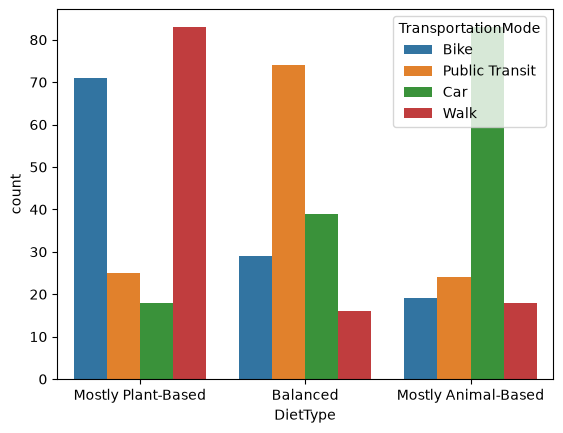

In [16]:
import seaborn as sns
sns.countplot(data=original_df, x="DietType", hue="TransportationMode")

<Axes: xlabel='DisposalMethods', ylabel='count'>

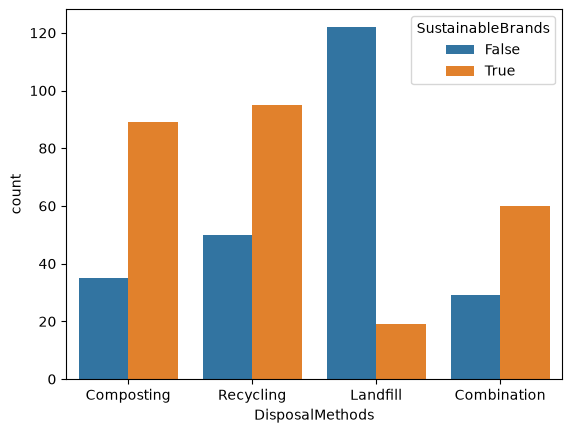

In [17]:
import seaborn as sns
sns.countplot(data=original_df, x="DisposalMethods", hue="SustainableBrands")